<a href="https://colab.research.google.com/github/jakob-steuer/chemoinformatics_2025/blob/main/chemoinformatics_6_qsar_nlp_search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Created with Google Gemini v2.5 Pro

In [ ]:
!pip install rdkit scikit-learn pandas umap-learn transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.2/36.2 MB 15.3 MB/s eta 0:00:00


# QSAR Exercise: Blood-Brain Barrier

One of the most important questions we can ask is: "Can this drug actually get to where it needs to go?"

For any drug targeting the brain (like antidepressants or Parkinson's medication), the answer must be "yes." For most other drugs (like a new antihistamine), the answer must be "no," or you get side effects like drowsiness.

The gatekeeper for this is the Blood-Brain Barrier (BBB), a highly selective membrane that protects the brain. Predicting whether a molecule can pass this barrier is a classic problem in ADMET (Absorption, Distribution, Metabolism, Excretion, and Toxicity) modeling.

In this exercise, we will build a complete QSAR (Quantitative Structure-Activity Relationship) model from scratch. Our goal is to train a machine learning algorithm to "learn" the chemical features that make a molecule either a "penetrator" or a "non-penetrator."

We will follow the fundamental chemoinformatics workflow:

- Load a dataset of molecules (SMILES) with known BBB penetration.

- Calculate key molecular descriptors (the "features") using RDKit.

- Train a Random Forest model to find the relationship between these features and the BBB property.

- Evaluate our model and, most importantly, interpret what it learned.

This is a core task to filter huge libraries of potential drugs down to a small number of promising candidates. L

In [ ]:
import pandas as pd

# Get BBBP dataset
url = 'https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/BBBP.csv'

# Load it into pandas
df = pd.read_csv(url)

# Inspect the data
print(df.head())
print(df.shape)

# The columns you need are 'smiles' and 'p_np' (penetration/non-penetration)
# 'p_np' is your target variable (y)
# 1 = Penetrates, 0 = Does NOT penetrate
print(df['p_np'].value_counts())

   num                  name  p_np  \
0    1            Propanolol     1   
1    2  Terbutylchlorambucil     1   
2    3                 40730     1   
3    4                    24     1   
4    5           cloxacillin     1   

                                              smiles  
0                   [Cl].CC(C)NCC(O)COc1cccc2ccccc12  
1           C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl  
2  c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...  
3                   C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C  
4  Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...  
(2050, 4)
p_np
1    1567
0     483
Name: count, dtype: int64


In [ ]:
df.head()

,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


## Feature Engineering - The "S" in QSAR

This is the most important chemoinformatics step.

We will use RDKit to convert "pictures" (SMILES) into "numbers" (descriptors).

In [ ]:
# Import RDKit & Define Functions:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

Create Mol Objects:

In [ ]:
# Convert SMILES to RDKit Mol objects
df['mol'] = df['smiles'].apply(lambda x: Chem.MolFromSmiles(x))

# Data Cleaning and Sanitization. Real-world datasets are never 100% perfect.
# Drop any molecules that RDKit couldn't parse
df = df.dropna(subset=['mol'])

[10:37:39] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not removing hydrogen atom without neighbors
[10:37:40] WARNING: not r

In [ ]:
# Check how many molecules survived cleaning
print(df['p_np'].value_counts())

p_np
1    1560
0     479
Name: count, dtype: int64



### Calculate Descriptors:

Let's write a function to calculate a few key descriptors that are known to be important for BBB penetration.

In [ ]:
def calculate_descriptors(mol):
    # Check if mol is valid
    if mol is None:
        return [None] * 5

    # Calculate descriptors
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    tpsa = Descriptors.TPSA(mol)
    h_donors = Descriptors.NumHDonors(mol)
    h_acceptors = Descriptors.NumHAcceptors(mol)

    return [mw, logp, tpsa, h_donors, h_acceptors]


# Apply the function to the 'mol' column
desc_cols = ['MW', 'LogP', 'TPSA', 'NumHDonors', 'NumHAcceptors']
df[desc_cols] = df['mol'].apply(lambda x: pd.Series(calculate_descriptors(x)))

# Drop any remaining rows with errors
df = df.dropna()
print(df.head())

   num                  name  p_np  \
0    1            Propanolol     1   
1    2  Terbutylchlorambucil     1   
2    3                 40730     1   
3    4                    24     1   
4    5           cloxacillin     1   

                                              smiles  \
0                   [Cl].CC(C)NCC(O)COc1cccc2ccccc12   
1           C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl   
2  c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...   
3                   C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C   
4  Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...   

                                                mol       MW     LogP    TPSA  \
0  <rdkit.Chem.rdchem.Mol object at 0x78a2bf2128f0>  294.802  3.26700   41.49   
1  <rdkit.Chem.rdchem.Mol object at 0x78a2bf212ff0>  360.325  4.63500   29.54   
2  <rdkit.Chem.rdchem.Mol object at 0x78a2bf213060>  361.373  1.54400   75.01   
3  <rdkit.Chem.rdchem.Mol object at 0x78a2bf212960>  290.407  2.57750   41.57   
4  <rdkit.Chem.rdchem.Mol obj

In [ ]:
# Check how many molecules survived descriptor calculation
print(df['p_np'].value_counts())

p_np
1    1560
0     479
Name: count, dtype: int64


**Why do we use these descriptors?**

We're choosing properties related to:

- size (MW)
- polarity (TPSA, H-Donors/Acceptors)
- lipophilicity (LogP)

These are the pillars of 'druglikeness'.

## Model Building

Now this is a "standard" machine learning problem.

Define X and y:

In [ ]:
from sklearn.model_selection import train_test_split

# X is our feature matrix (the descriptors)
X = df[desc_cols]

# y is our target variable (what we want to predict)
y = df['p_np']

Split Data:

In [ ]:
# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (1631, 5)
Test set size: (408, 5)


Train a Model:

A **Random Forest** is perfect.

It's fast, robust, and doesn't require feature scaling.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


## Evaluation & Interpretation

Did our model learn anything?

Make Predictions:

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Predict on the unseen test set
y_pred = model.predict(X_test)

Check Metrics:

Model Accuracy: 0.87


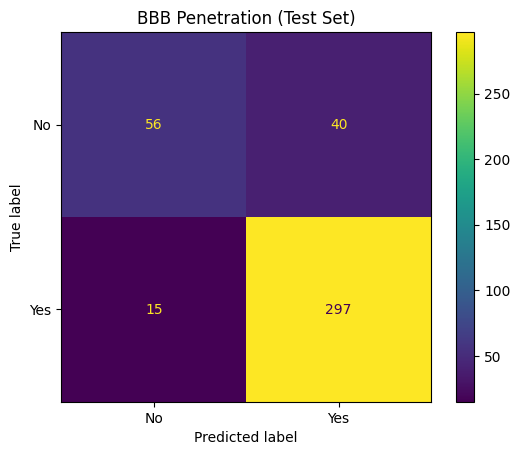

In [ ]:
# How did we do?
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Show the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot()
plt.title("BBB Penetration (Test Set)")
plt.show()

**What does this matrix mean?**

What's a False Positive?

What's a False Negative?

Which is worse for a brain drug?

The confusion matrix is a simple but powerful grid that shows you exactly how your model is "confused." It compares the actual (true) labels of the molecules to the predictions your model made.

It's the ultimate report card because it doesn't just give you a single grade (like "85% accuracy"); it shows you where you lost points.

It has **four quadrants**:

True Positives (TP): Your model predicted "Yes" (it crosses), and the reality was "Yes." (A correct hit)

True Negatives (TN): Your model predicted "No" (it doesn't cross), and the reality was "No." (A correct rejection)

False Positives (FP): Your model predicted "Yes" (it crosses), but the reality was "No." (A false alarm)

False Negatives (FN): Your model predicted "No" (it doesn't cross), but the reality was "Yes." (A missed target)

❓ **What's a False Positive?**

Prediction: The model says "Yes, this drug WILL cross the BBB." Reality: The drug does NOT cross the BBB.

This is the model being over-optimistic. It's a "false alarm".

❓ **What's a False Negative?**

Prediction: The model says "No, this drug will NOT cross the BBB." Reality: The drug DOES cross the BBB.

This is the model being over-pessimistic. It's a "missed target" .


**Which is Worse for a Brain Drug?**
For a drug that must get into the brain to work (like an Alzheimer's or antidepressant drug), a False Positive is the worse error.

Here’s the simple, practical reason:

A False Negative (model says "No," reality is "Yes") means you miss a good molecule. You discard a promising candidate and never test it. This is a missed opportunity, which is bad.

A False Positive (model says "Yes," reality is "No") means you select a bad molecule. You take this useless candidate, spend thousands (or millions) of dollars and months of time synthesizing it, testing it in labs, and putting it into clinical trials... only to have it fail guaranteed because it can't even reach its target in the brain.

A False Negative is a "missed shot." A False Positive is a "wasted shot." In drug discovery, wasting resources on a guaranteed failure (a False Positive) is a more costly and damaging error than missing one potential hit.

## Interpret the Model (The QSAR part):

This is the most valuable step. **What did the model learn?**

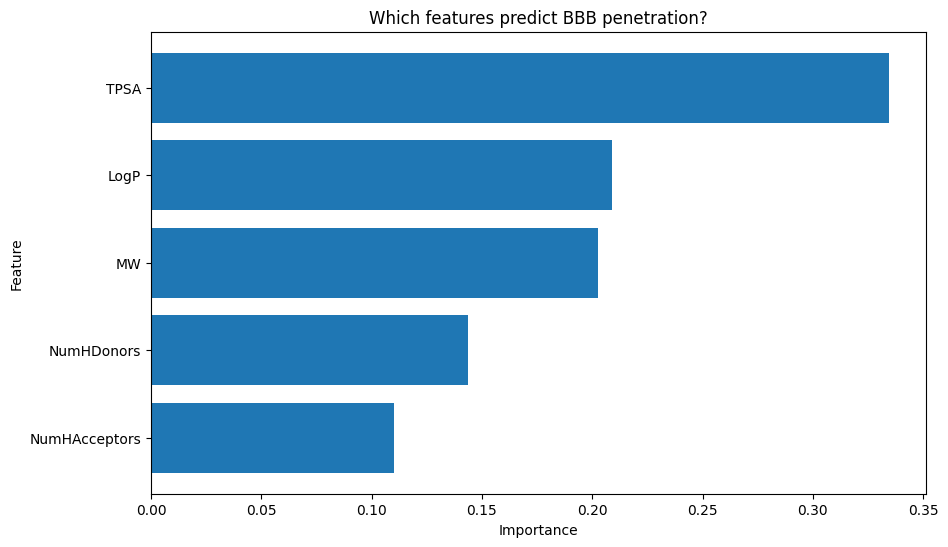

In [ ]:
# Get feature importances
importances = model.feature_importances_

# Create a nice plot
feat_importance_df = pd.DataFrame(
    {'Feature': desc_cols, 'Importance': importances}
).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Which features predict BBB penetration?')
plt.gca().invert_yaxis() # Show most important at the top
plt.show()

**Looking at the plot, what is the most important feature?**

Does this make chemical sense?

Molecules that are highly polar (high TPSA), too water-soluble (low LogP) or to big (high MW) struggle to cross the fatty (lipid) barrier of the brain."

# Visualization

## Setup & High-Dimensional Featurization

For our QSAR model, we used 5 human-chosen descriptors.

To map 'all' of chemistry, we need a more general, high-dimensional representation.

We'll use Morgan Fingerprints (or ECFPs).

They convert each molecule into a long vector (e.g., 2048 numbers) that represents its substructures.

In [ ]:
from rdkit.Chem import AllChem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
import numpy as np

# Create the fingerprint generator
# We use fpSize (fingerprint size) instead of nBits
morgan_gen = GetMorganGenerator(radius=2, fpSize=2048)

def get_fingerprint(mol):
    # Use the generator to get the fingerprint
    # We also use GetFingerprintAsBitVect *from the generator object*
    fp = morgan_gen.GetFingerprint(mol)
    return np.array(fp)

# (Use the 'mol' column from the QSAR exercise)
print("Calculating fingerprints...")
fp_list = [get_fingerprint(m) for m in df['mol']]

# Convert to a big NumPy array
X_fp = np.array(fp_list)
print(f"Fingerprint matrix shape: {X_fp.shape}")
print("Fingerprints calculated successfully!")

Calculating fingerprints...
Fingerprint matrix shape: (2039, 2048)
Fingerprints calculated successfully!


## Dimensionality Reduction with UMAP (15 minutes)
This is the "magic" step. We're "squishing" 2048 dimensions down to 2.

In [ ]:
import umap
import matplotlib.pyplot as plt

# Initialize the UMAP reducer
# n_neighbors controls "local" vs "global" structure
reducer = umap.UMAP(n_neighbors=10, min_dist=0.01, random_state=41)

print("Fitting UMAP... (this may take a minute)")
# Fit and transform the high-dimensional data (X_fp) to 2D
embedding = reducer.fit_transform(X_fp)

print(f"New 'embedding' shape: {embedding.shape}")

Fitting UMAP... (this may take a minute)


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


New 'embedding' shape: (2039, 2)


## First Visualization: The "Map"

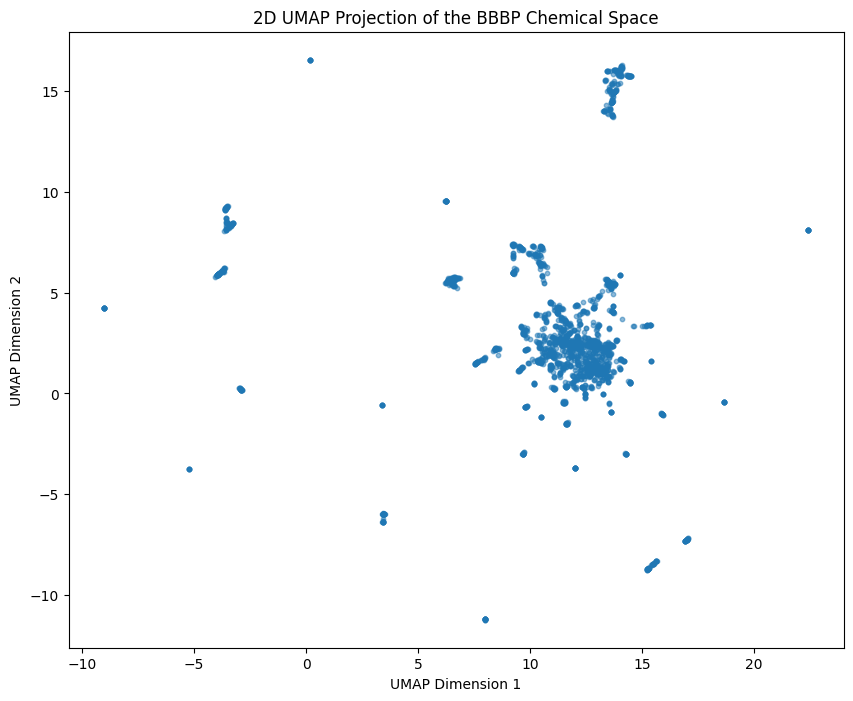

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], s=10, alpha=0.5) # s=size, alpha=transparency

plt.title("2D UMAP Projection of the BBBP Chemical Space")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

This is the 'Chemical Universe' of our dataset.

Each dot is a molecule.

Dots that are close together are structurally similar.


## Visualizing the Property Landscape

Now we color the map.

Visualization 1: Color by BBB Penetration (The QSAR Target)

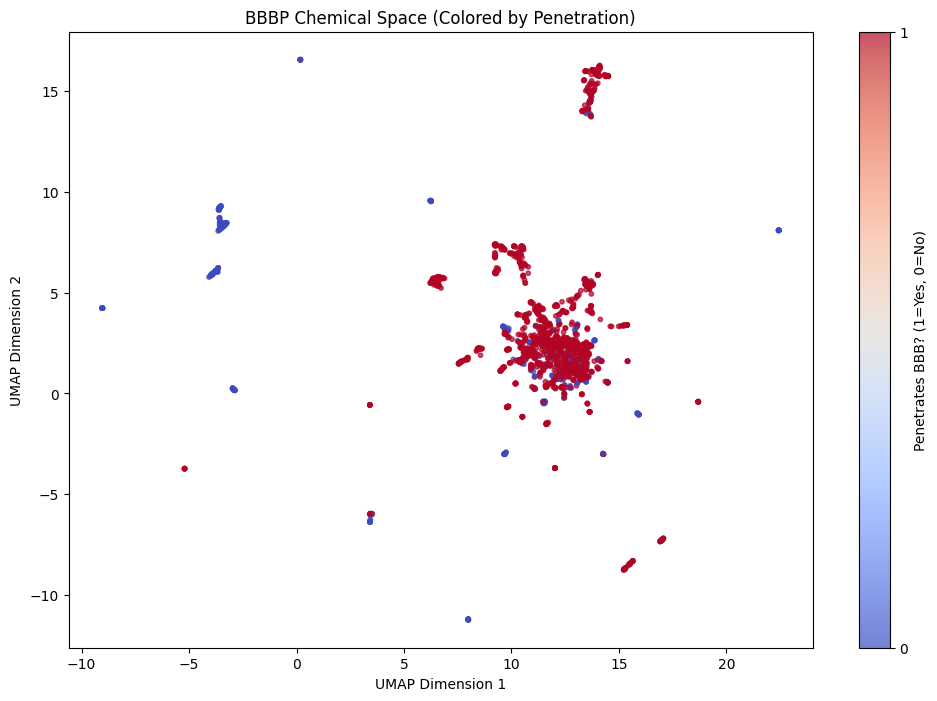

In [ ]:
# Get the labels (y) from our QSAR exercise (the 'p_np' column)
labels = df['p_np']

plt.figure(figsize=(12, 8))
# Use 'c=labels' to color the points by the 0 or 1 value
plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap='coolwarm', s=10, alpha=0.7)

plt.colorbar(ticks=[0, 1]).set_label("Penetrates BBB? (1=Yes, 0=No)")
plt.title("BBBP Chemical Space (Colored by Penetration)")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.show()

Look at the map.

Are the 'Yes' (red) and 'No' (blue) molecules in different 'countries'? Or are they all mixed?

This shows us how 'separable' the problem is.

Our QSAR model is an algorithm that learned to draw the border between the red and blue regions."

# The AI Research Assistant (Language Model Q&A)

This exercise uses a Natural Language Processing (NLP) model to perform **extractive** question-answering.

It simulates how an AI can "read" a scientific paper or a drug summary to find specific ADMET-related facts.


Concept:

- Provide the model with a "context" (a block of text about a drug).

- Ask the model specific questions (e.g., "What is the bioavailability?", "What is the main toxicity?").

- The model will find and extract the answer from the text.



In [1]:
# Load Pipeline and Define Context:

from transformers import pipeline

# Load the pre-trained question-answering pipeline
qa_pipeline = pipeline("question-answering")

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [2]:
# A sample context about a well-known drug
context = """
Paracetamol, also known as acetaminophen, is a widely used over-the-counter medication.
It is well-absorbed, with an oral bioavailability of approximately 88%.
Metabolism occurs primarily in the liver, mainly through glucuronidation and sulfation.
A minor fraction is metabolized by CYP450 enzymes to a toxic intermediate, NAPQI.
At therapeutic doses, NAPQI is safely detoxified by glutathione.
However, in cases of overdose, glutathione is depleted, and NAPQI causes severe liver damage (hepatotoxicity).
"""

Note:

This is an 'extractive' model.
It doesn't 'know' the answer, but it's an expert at finding the answer in a text.

However, imagine pointing this model at 10,000 research papers. You could ask, 'Which papers mention hERG toxicity?' in seconds."

In [3]:
# Ask ADMET Questions
print("--- Running AI Research Assistant ---")

# Question 1: Absorption
q1 = "What is the oral bioavailability of Paracetamol?"
result1 = qa_pipeline(question = q1, context = context)
print(f"Q: {q1}\nA: {result1['answer']} (Score: {result1['score']:.2f})\n")

# Question 2: Metabolism
q2 = "Where is Paracetamol metabolized?"
result2 = qa_pipeline(question = q2, context = context)
print(f"Q: {q2}\nA: {result2['answer']} (Score: {result2['score']:.2f})\n")

# Question 3: Toxicity
q3 = "What is the main toxicity in case of overdose?"
result3 = qa_pipeline(question = q3, context = context)
print(f"Q: {q3}\nA: {result3['answer']} (Score: {result3['score']:.2f})\n")

# Question 4: A specific metabolite
q4 = "What is the name of the toxic intermediate?"
result4 = qa_pipeline(question = q4, context = context)
print(f"Q: {q4}\nA: {result4['answer']} (Score: {result4['score']:.2f})\n")

print("--- Exercise complete ---")

--- Running AI Research Assistant ---
Q: What is the oral bioavailability of Paracetamol?
A: 88% (Score: 0.82)

Q: Where is Paracetamol metabolized?
A: NAPQI (Score: 0.53)

Q: What is the main toxicity in case of overdose?
A: glutathione (Score: 0.44)

Q: What is the name of the toxic intermediate?
A: NAPQI (Score: 0.97)

--- Exercise complete ---


**Overall Interpretation**

The model is very good at "CTRL+F" on steroids. It can find the exact answer when the question's wording closely matches the text. However, it struggles with "why" or "how" and can be easily confused by complex sentences, leading it to find the wrong type of answer.

The score is a measure of its confidence, and in this case, it was a very good predictor of accuracy.


**1. The Good (High Confidence, Correct)**

Q: What is the oral bioavailability of Paracetamol? A: 88% (Score: 0.82)

Interpretation: Perfectly correct. The model found the phrase "oral bioavailability of approximately 88%" in the text, matched it to the question, and correctly extracted the "88%". The high score shows it was very confident.

Q: What is the name of the toxic intermediate? A: NAPQI (Score: 0.97)

Interpretation: Perfectly correct. The text almost certainly contained the exact phrase "toxic intermediate, NAPQI". This was a simple "fill-in-the-blank" for the model. The near-perfect score (0.97) shows it found an exact match.


**2. The Bad (Low Confidence, Incorrect)**

Q: Where is Paracetamol metabolized? A: NAPQI (Score: 0.53)

Interpretation: Completely incorrect.

The Mistake: The question asks "Where?" (a location). The correct answer is "in the liver". The model answered "NAPQI", which is a what (a metabolite).

Why it Failed: The model saw the word "metabolized" in the text near the word "NAPQI" (e.g., "...metabolized...to a toxic intermediate, NAPQI."). It latched onto the wrong word because it was close.

The Score: The low score (0.53) shows the model was "on the fence" and not very sure. It's a good sign that a low score correlates with a bad answer.

**Q: What is the main toxicity in case of overdose? A: glutathione (Score: 0.44)**

Interpretation: Completely incorrect. This is the most interesting failure.

The Mistake: "Glutathione" is the antidote (the good guy!) that prevents toxicity. The correct answer is "liver damage" or "hepatotoxicity".

Why it Failed: The text likely said something like "...glutathione is depleted, and NAPQI causes...hepatotoxicity...". The model saw "toxicity" and "glutathione" in the same sentence and got confused. It failed to understand the relationship between them (one stops the other).

The Score: The very low score (0.44) shows the model was basically guessing. It found a weak association and reported it.

Key Takeaways

**This model is Extractive, not Abstractive:** It doesn't "understand" biology. It just finds and "extracts" the piece of text that looks like the best answer.

**Beware of "Keyword Closeness":** The model will often fail by grabbing a word that is near the keyword in the question but is not the right type of answer (e.g., answering "What" to a "Where" question).

**The Confidence Score is Critical:** The scores were a great guide. The high-scoring answers were correct "exact matches," while the low-scoring answers were "confused guesses." In an automated pipeline, you would filter out any answers with a score below 0.7.

## How to Improve the Model

Here are three ways to get better answers, from a simple swap to a more advanced approach.

### 1. Use a Domain-Specific Extractive Model
This is the easiest and most direct improvement. The default model was trained on general text (news, Wikipedia). We can swap it with one trained specifically on biomedical and scientific papers.

These models will have a much better vocabulary and understanding of terms like "metabolite," "bioavailability," and "hepatotoxicity."

Examples (Hugging Face):

BioBERT: dmis-lab/biobert-base-cased-v1.1-squad (Trained on biomedical literature)

SciBERT: allenai/scibert_scivocab_cased (Trained on a broad corpus of scientific papers)

In [ ]:
# Specify the BioBERT model trained on the SQuAD dataset
qa_pipeline_bio = pipeline(
    "question-answering",
    model="dmis-lab/biobert-base-cased-v1.1-squad"
)

q1 = "Where is Paracetamol metabolized?"
q2 = "What is the main toxicity in case of overdose?"

print(qa_pipeline_bio(question = q1, context = context))
print(qa_pipeline_bio(question = q2, context = context))

Some weights of the model checkpoint at dmis-lab/biobert-base-cased-v1.1-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cpu


{'score': 0.12308807671070099, 'start': 194, 'end': 203, 'answer': 'the liver'}
{'score': 0.1483218832872808, 'start': 495, 'end': 509, 'answer': 'hepatotoxicity'}


Expected Result: This model is much more likely to correctly answer "in the liver" and "severe liver damage (hepatotoxicity)" because it has been trained on this type of text.

### 2. Use an Abstractive Model (e.g., T5, BART)
The next step up is to use an abstractive model. Unlike extractive models, these models generate a new answer in their own words. They can synthesize information from multiple parts of the text.

This is a different task, often called text-generation or summarization, but you can frame the input to get a Q&A behavior.

How to implement (using T5):

In [ ]:
# Load a T5 model, which is great at text-to-text tasks
# We frame the problem: "question: [Q] context: [C]"
qa_pipeline_t5 = pipeline(
    "text2text-generation",
    model="google/flan-t5-base"
)

# We must now combine the question and context in the input
input_text_q1 = f"question: {q1} context: {context}"
input_text_q2 = f"question: {q2} context: {context}"

print(f"Q: {q1}")
print(f"A: {qa_pipeline_t5(input_text_q1)[0]['generated_text']}\n")

print(f"Q: {q2}")
print(f"A: {qa_pipeline_t5(input_text_q2)[0]['generated_text']}")

Device set to use cpu


Q: Where is Paracetamol metabolized?
A: CYP450 enzymes

Q: What is the main toxicity in case of overdose?
A: hepatotoxicity


Expected Result: You will get a natural-language answer (e.g., "in the liver" or "severe liver damage") that is generated by the model, not just copied.

### 3. Use a Full Generative LLM (The "Reasoning" Approach)

This is the most powerful method and is closer to how a human (or a system like ChatGPT) works. You use a large generative model and provide the context as a "prompt," asking it to reason and answer.

Models: This includes models like Llama, Mistral, or the new google/gemma-7b (all available on Hugging Face).

Strategy: This approach, known as Retrieval-Augmented Generation (RAG), is the state-of-the-art. You first "retrieve" the relevant text (our context block) and then "augment" a generative model's prompt with that text.

This is more complex to run in a Colab (it requires a powerful GPU and more code), but it's the ultimate solution because the model can reason about the text, understand the "antidote" relationship, and answer correctly.